# Customer Churn Predictor — Complete Analysis

**Final Project | Intro to Data Science | Prof. Yrupe Fresco**

---

## Project Overview

This notebook documents the full pipeline of a churn prediction model built from **GitHub API** data:

| Stage | Description |
|---|---|
| 1 — Data Pipeline | Scraped 300 user profiles via 5 API endpoints |
| 2 — Feature Generation | Engineered 20 features across 4 categories |
| 3 — Feature Selection | Applied 4 methods + cross-method consensus |
| 4 — Model Training | Random Forest on 11 selected features |
| 5 — Prediction API | Dockerized FastAPI `/predict` endpoint |

**Data source:** GitHub public API | **Churn definition:** inactive > 180 days (last repo push) | **Class balance:** 39.7% churned

### Tech Stack
- Python 3.11 + FastAPI + scikit-learn + pandas
- Docker + docker-compose
- Jupyter / matplotlib / seaborn for analysis and visualization

In [1]:
# === Imports & Setup ===
import sys, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

project_root = Path.cwd().resolve()
while not (project_root / "app" / "features.py").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 5)

print("Project root:", project_root)
print("Ready.")

Project root: /home/javier/Escritorio/churn-predictor
Ready.


## 1. Data Pipeline

### How the scraper works

`app/scraper.py` fetches data from **5 GitHub API endpoints** per user:

| Endpoint | Data Collected |
|---|---|
| `GET /users/{username}` | Profile info: followers, following, repos, gists, hireable, dates, bio |
| `GET /users/{username}/repos` | Per-repo: stars, forks, size, issues, language, pushed_at |
| `GET /users/{username}/events` | Last 30 days events (max 300): types, counts, most recent |
| `GET /users/{username}/starred` | Count of starred repos |
| `GET /users/{username}/orgs` | Count of organization memberships |

The scraper handles pagination, 404s (skip user), and 429 rate limits (sleep 60s and retry). With a GitHub token (5,000 req/hr), the inter-request delays were removed.

### Raw data exploration

In [2]:
from app.features import ROOT, FEATURE_COLS, load_raw_data

raw = load_raw_data()
print(f"Users loaded: {len(raw)}")
print(f"Raw columns: {len(raw.columns)}")
raw.head()

Users loaded: 300
Raw columns: 38


,username,id,followers,following,public_repos,public_gists,hireable,created_at,updated_at,bio,...,most_recent_event,distinct_event_types_count,event_types_json,total_starred,total_orgs,has_invested_profile,has_no_repos,is_b2b_affiliated,is_actively_hireable,has_external_gists
0,mojombo,1,24639,11,66,62,NaN,2007-10-20 05:24:19+00:00,2026-05-29 01:54:43+00:00,NaN,...,NaT,0,{},164,1,False,False,True,False,True
1,defunkt,2,22710,215,107,274,NaN,2007-10-20 05:24:19+00:00,2025-08-08 19:18:26+00:00,🍔,...,NaT,0,{},200,1,False,False,True,False,True
2,pjhyett,3,8402,30,8,21,NaN,2008-01-07 17:54:22+00:00,2026-04-07 17:46:52+00:00,NaN,...,NaT,0,{},15,0,False,False,False,False,True
3,wycats,4,10308,13,331,767,NaN,2008-01-12 05:38:33+00:00,2026-06-12 15:49:52+00:00,NaN,...,2026-06-15 05:03:44+00:00,9,"{'PushEvent': 22, 'CreateEvent': 15, 'ForkEven...",200,15,False,False,True,False,True
4,ezmobius,5,607,13,22,106,NaN,2008-01-12 07:51:46+00:00,2026-05-22 11:32:36+00:00,NaN,...,NaT,0,{},94,1,False,False,True,False,True


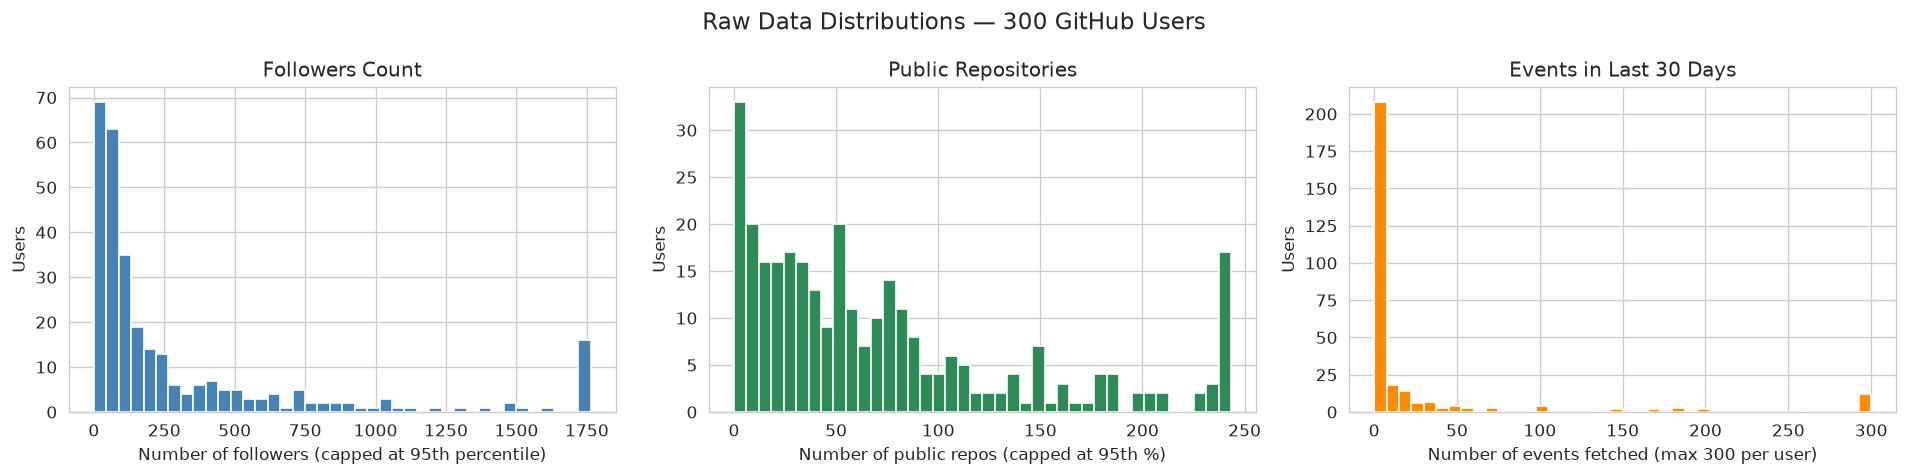

In [3]:
# Raw data distributions — each variable shown with a meaningful cap
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Followers: most users have 0-500, cap at P95
ax = axes[0]
followers_ = raw["followers"].clip(upper=raw["followers"].quantile(0.95))
ax.hist(followers_, bins=40, color="steelblue", edgecolor="white")
ax.set_title("Followers Count")
ax.set_xlabel("Number of followers (capped at 95th percentile)")
ax.set_ylabel("Users")

# Public repos: cap at P95
ax = axes[1]
repos_ = raw["public_repos"].clip(upper=raw["public_repos"].quantile(0.95))
ax.hist(repos_, bins=40, color="seagreen", edgecolor="white")
ax.set_title("Public Repositories")
ax.set_xlabel("Number of public repos (capped at 95th %)")
ax.set_ylabel("Users")

# Events: natural cap at 300 (GitHub API limit)
ax = axes[2]
ax.hist(raw["total_events_fetched"], bins=40, color="darkorange", edgecolor="white")
ax.set_title("Events in Last 30 Days")
ax.set_xlabel("Number of events fetched (max 300 per user)")
ax.set_ylabel("Users")

plt.suptitle("Raw Data Distributions — 300 GitHub Users", fontsize=14)
plt.tight_layout()
plt.show()

### Churn Label Definition

A user is **churned** if their most recent push across all repos is > 180 days ago:

```
churned = (today - most_recent_repo_push).days > 180
```

**Why 180 days:** GitHub users often alternate between intense sprints and quiet periods. 30 days catches a vacation, 365 is too permissive. 180 days (6 months) captures meaningful disengagement.

**Why repo push, not events:** The `/events` endpoint only covers 30 days of data. A user with zero events could be on vacation or truly churned — we can't tell. `pushed_at` from repos has no time limit except the repo's creation date.

## 2. Feature Generation

20 features were engineered from raw GitHub data. Each feature type encodes a different aspect of user behavior:

| Type | Count | Examples |
|---|---|---|
| **Ratio** | 7 | `follower_to_following_ratio`, `stars_per_repository`, `repos_per_year` |
| **Time** | 4 | `days_since_last_api_activity`, `profile_staleness_days`, `average_days_between_events` |
| **Aggregation** | 5 | `aggregate_codebase_footprint_kb`, `distinct_event_types_count`, `total_community_validation_count` |
| **Binary** | 4 | `has_no_repos`, `is_b2b_affiliated`, `has_invested_profile`, `is_actively_hireable` |

In [4]:
from app.features import compute_features

df = compute_features(raw)
print(f"Feature matrix: {df.shape[0]} users x {len(FEATURE_COLS)} features")
print(f"Churn rate: {df['churned'].mean():.1%} ({df['churned'].sum():.0f}/{len(df)} users)")

# List all features by type
for ftype, names in {
    "Ratio": FEATURE_COLS[:7],
    "Time": FEATURE_COLS[7:11],
    "Aggregation": FEATURE_COLS[11:16],
    "Binary": FEATURE_COLS[16:],
}.items():
    print(f"\n{ftype} ({len(names)}):")
    for n in names:
        print(f"  • {n}")

Feature matrix: 300 users x 23 features
Churn rate: 39.7% (119/300 users)

Ratio (7):
  • follower_to_following_ratio
  • stars_per_repository
  • fork_to_repo_ratio
  • open_issues_per_repo
  • code_to_profile_age_ratio
  • push_to_total_events_ratio
  • repos_per_year

Time (4):
  • days_since_last_api_activity
  • average_days_between_events
  • profile_staleness_days
  • total_community_validation_count

Aggregation (5):
  • total_starred_by_user
  • total_organization_connections
  • aggregate_codebase_footprint_kb
  • distinct_event_types_count
  • has_no_repos

Binary (7):
  • is_b2b_affiliated
  • has_invested_profile
  • is_actively_hireable
  • has_external_gists
  • degree_centrality
  • betweenness_centrality
  • pagerank


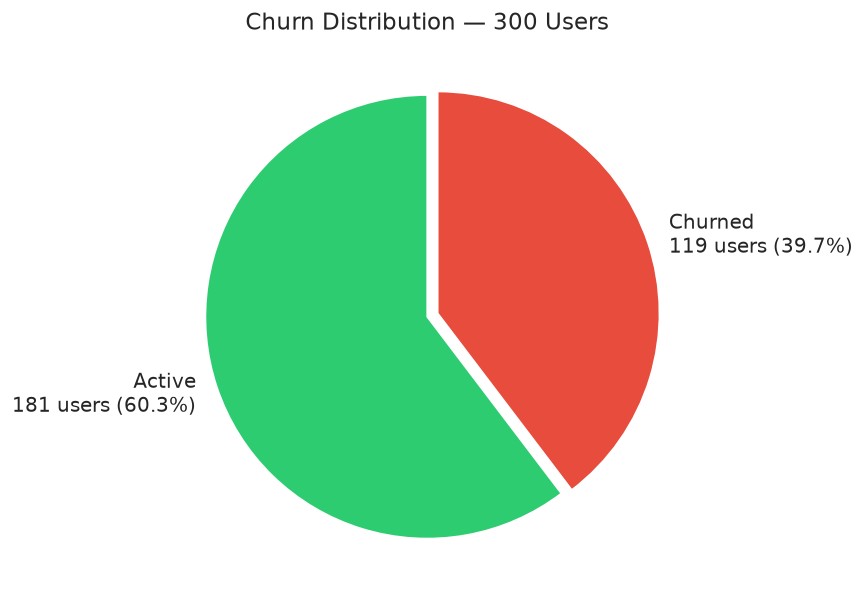

In [5]:
# Churn distribution pie chart
fig, ax = plt.subplots(figsize=(6, 6))
counts = df["churned"].value_counts()
colors_pie = ["#2ecc71", "#e74c3c"]
labels_pie = [
    f"Active\n{counts[0]} users ({counts[0]/len(df):.1%})",
    f"Churned\n{counts[1]} users ({counts[1]/len(df):.1%})",
]
ax.pie(counts, labels=labels_pie, colors=colors_pie, startangle=90, explode=(0, 0.05),
       textprops={"fontsize": 12})
ax.set_title("Churn Distribution — 300 Users", fontsize=14)
plt.show()

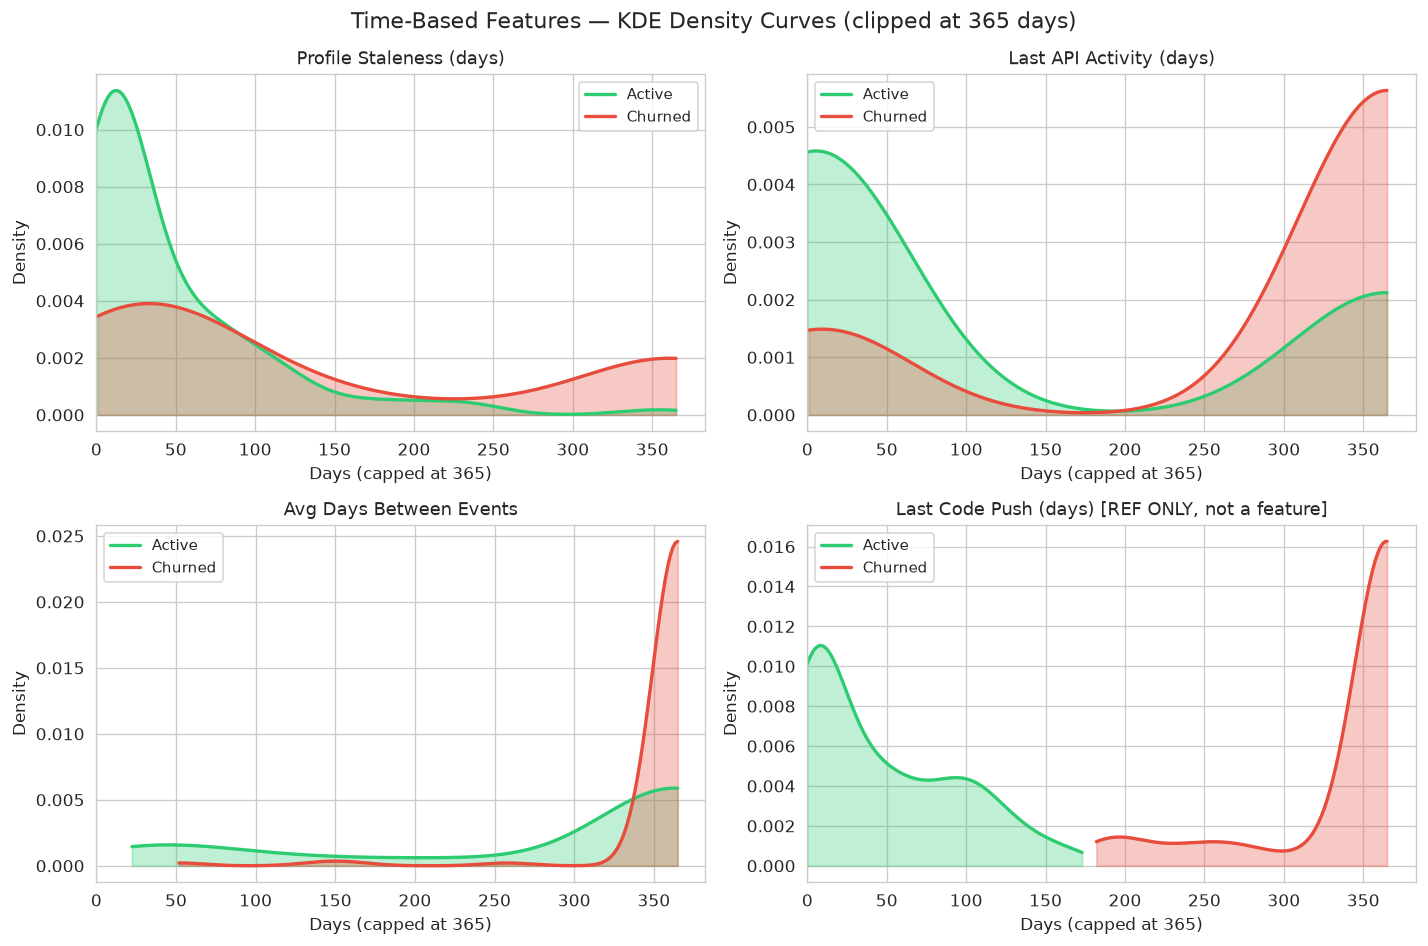

Median values per class (capped at 365):


,Feature,Active (med),Churned (med),Ratio
0,Profile Staleness,18d,68d,3.8x
1,Last API Activity,6d,365d,60.8x
2,Avg Days Between Events,365d,365d,1.0x
3,Last Code Push,29d,365d,12.6x



Note: days_since_last_code_push is shown for reference only — it is NOT used as a model feature.
      (churn IS defined as days_since_last_code_push > 180 — including it would be circular)


In [6]:
# Time-based features — capped KDE distributions by churn class
# Values > 365 days are capped at 365 for readability (9999 NaNs → censored to 365)
import numpy as np

CAP_DAYS = 365

time_display = [
    ("profile_staleness_days",       "Profile Staleness (days)"),
    ("days_since_last_api_activity", "Last API Activity (days)"),
    ("average_days_between_events",  "Avg Days Between Events"),
    ("days_since_last_code_push",    "Last Code Push (days) [REF ONLY, not a feature]"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, (feat, title) in enumerate(time_display):
    ax = axes[i // 2, i % 2]
    for c, lab, col in [(0, "Active", "#2ecc71"), (1, "Churned", "#e74c3c")]:
        vals = df.loc[df["churned"] == c, feat].clip(upper=CAP_DAYS)
        if len(vals) > 1:
            from scipy.stats import gaussian_kde
            try:
                kde = gaussian_kde(vals)
                x_range = np.linspace(vals.min(), vals.max(), 200)
                ax.fill_between(x_range, kde(x_range), alpha=0.3, color=col)
                ax.plot(x_range, kde(x_range), color=col, linewidth=2, label=lab)
            except Exception:
                ax.hist(vals, bins=25, alpha=0.4, color=col, label=lab)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Days (capped at 365)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)
    ax.set_xlim(left=0)

plt.suptitle("Time-Based Features — KDE Density Curves (clipped at 365 days)", fontsize=13)
plt.tight_layout()
plt.show()

# Summary statistics: median per class
print("Median values per class (capped at 365):")
stats_rows = []
for feat, title in time_display:
    act_med = df.loc[df["churned"] == 0, feat].clip(upper=CAP_DAYS).median()
    chn_med = df.loc[df["churned"] == 1, feat].clip(upper=CAP_DAYS).median()
    ratio = chn_med / act_med if act_med > 0 else float("inf")
    stats_rows.append({"Feature": title.split(" (")[0], "Active (med)": f"{act_med:.0f}d", "Churned (med)": f"{chn_med:.0f}d", "Ratio": f"{ratio:.1f}x"})
display(pd.DataFrame(stats_rows))

print("\nNote: days_since_last_code_push is shown for reference only — it is NOT used as a model feature.")
print("      (churn IS defined as days_since_last_code_push > 180 — including it would be circular)")


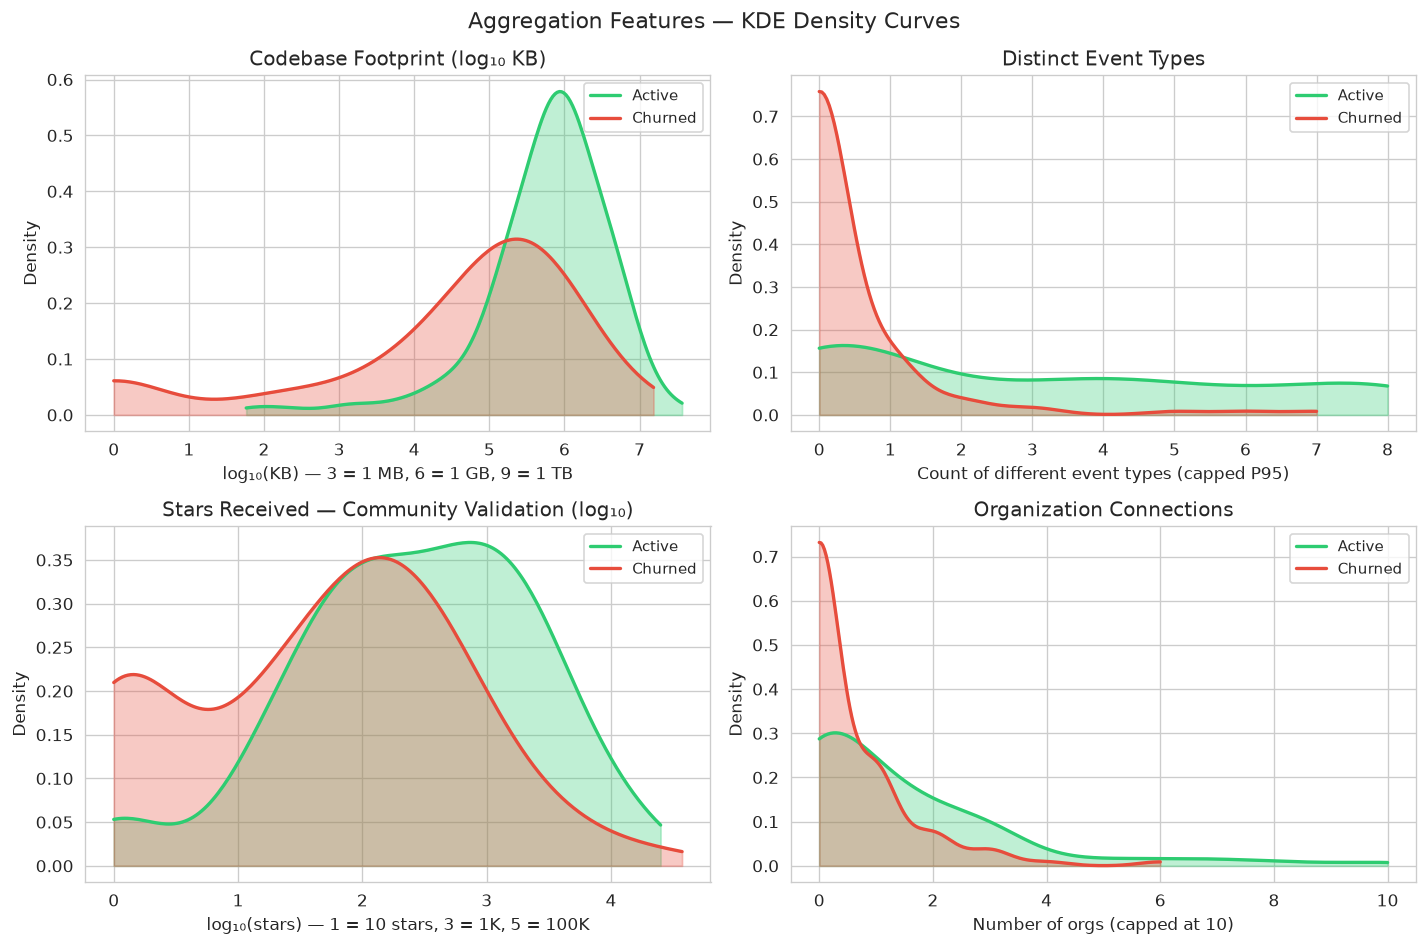

Median values per class:


,Feature,Active (med),Churned (med),Ratio
0,Codebase Footprint (KB),"793,611","142,055",0.2x
1,Distinct Event Types,2,0,0.0x
2,Stars Received,273,70,0.3x
3,Organization Conns,1,0,0.0x


In [7]:
# Aggregation features — KDE density by churn class
# Codebase footprint & stars use log₁₀ scale (span 0 → 10¹³)
# Event types & orgs use linear scale with P95 cap

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# --- Codebase footprint: log₁₀ KDE ---
ax = axes[0, 0]
for c, lab, col in [(0, "Active", "#2ecc71"), (1, "Churned", "#e74c3c")]:
    vals = df.loc[df["churned"] == c, "aggregate_codebase_footprint_kb"]
    vals_log = np.log10(vals.clip(lower=1))
    if len(vals_log) > 1:
        from scipy.stats import gaussian_kde
        try:
            kde = gaussian_kde(vals_log)
            x_range = np.linspace(vals_log.min(), vals_log.max(), 200)
            ax.fill_between(x_range, kde(x_range), alpha=0.3, color=col)
            ax.plot(x_range, kde(x_range), color=col, linewidth=2, label=lab)
        except Exception:
            ax.hist(vals_log, bins=25, alpha=0.4, color=col, label=lab)
ax.set_title("Codebase Footprint (log₁₀ KB)")
ax.set_xlabel("log₁₀(KB) — 3 = 1 MB, 6 = 1 GB, 9 = 1 TB")
ax.set_ylabel("Density")
ax.legend(fontsize=9)

# --- Distinct event types: linear KDE ---
ax = axes[0, 1]
cap = df["distinct_event_types_count"].quantile(0.95)
for c, lab, col in [(0, "Active", "#2ecc71"), (1, "Churned", "#e74c3c")]:
    vals = df.loc[df["churned"] == c, "distinct_event_types_count"].clip(upper=cap)
    if len(vals) > 1:
        from scipy.stats import gaussian_kde
        try:
            kde = gaussian_kde(vals)
            x_range = np.linspace(vals.min(), vals.max(), 200)
            ax.fill_between(x_range, kde(x_range), alpha=0.3, color=col)
            ax.plot(x_range, kde(x_range), color=col, linewidth=2, label=lab)
        except Exception:
            ax.hist(vals, bins=15, alpha=0.4, color=col, label=lab)
ax.set_title("Distinct Event Types")
ax.set_xlabel("Count of different event types (capped P95)")
ax.set_ylabel("Density")
ax.legend(fontsize=9)

# --- Community validation: log₁₀ KDE ---
ax = axes[1, 0]
for c, lab, col in [(0, "Active", "#2ecc71"), (1, "Churned", "#e74c3c")]:
    vals = df.loc[df["churned"] == c, "total_community_validation_count"]
    vals_log = np.log10(vals.clip(lower=1))
    if len(vals_log) > 1:
        from scipy.stats import gaussian_kde
        try:
            kde = gaussian_kde(vals_log)
            x_range = np.linspace(vals_log.min(), vals_log.max(), 200)
            ax.fill_between(x_range, kde(x_range), alpha=0.3, color=col)
            ax.plot(x_range, kde(x_range), color=col, linewidth=2, label=lab)
        except Exception:
            ax.hist(vals_log, bins=25, alpha=0.4, color=col, label=lab)
ax.set_title("Stars Received — Community Validation (log₁₀)")
ax.set_xlabel("log₁₀(stars) — 1 = 10 stars, 3 = 1K, 5 = 100K")
ax.set_ylabel("Density")
ax.legend(fontsize=9)

# --- Organization connections: linear KDE ---
ax = axes[1, 1]
for c, lab, col in [(0, "Active", "#2ecc71"), (1, "Churned", "#e74c3c")]:
    vals = df.loc[df["churned"] == c, "total_organization_connections"].clip(upper=10)
    if len(vals) > 1:
        from scipy.stats import gaussian_kde
        try:
            kde = gaussian_kde(vals)
            x_range = np.linspace(vals.min(), vals.max(), 200)
            ax.fill_between(x_range, kde(x_range), alpha=0.3, color=col)
            ax.plot(x_range, kde(x_range), color=col, linewidth=2, label=lab)
        except Exception:
            ax.hist(vals, bins=12, alpha=0.4, color=col, label=lab)
ax.set_title("Organization Connections")
ax.set_xlabel("Number of orgs (capped at 10)")
ax.set_ylabel("Density")
ax.legend(fontsize=9)

plt.suptitle("Aggregation Features — KDE Density Curves", fontsize=13)
plt.tight_layout()
plt.show()

# Summary statistics: median per class
print("Median values per class:")
agg_display = [
    ("aggregate_codebase_footprint_kb",    "Codebase Footprint (KB)"),
    ("distinct_event_types_count",         "Distinct Event Types"),
    ("total_community_validation_count",    "Stars Received"),
    ("total_organization_connections",      "Organization Conns"),
]
agg_stats = []
for feat, title in agg_display:
    act_med = df.loc[df["churned"] == 0, feat].median()
    chn_med = df.loc[df["churned"] == 1, feat].median()
    ratio = chn_med / act_med if act_med > 0 else float("inf")
    agg_stats.append({"Feature": title, "Active (med)": f"{act_med:,.0f}", "Churned (med)": f"{chn_med:,.0f}", "Ratio": f"{ratio:.1f}x"})
display(pd.DataFrame(agg_stats))


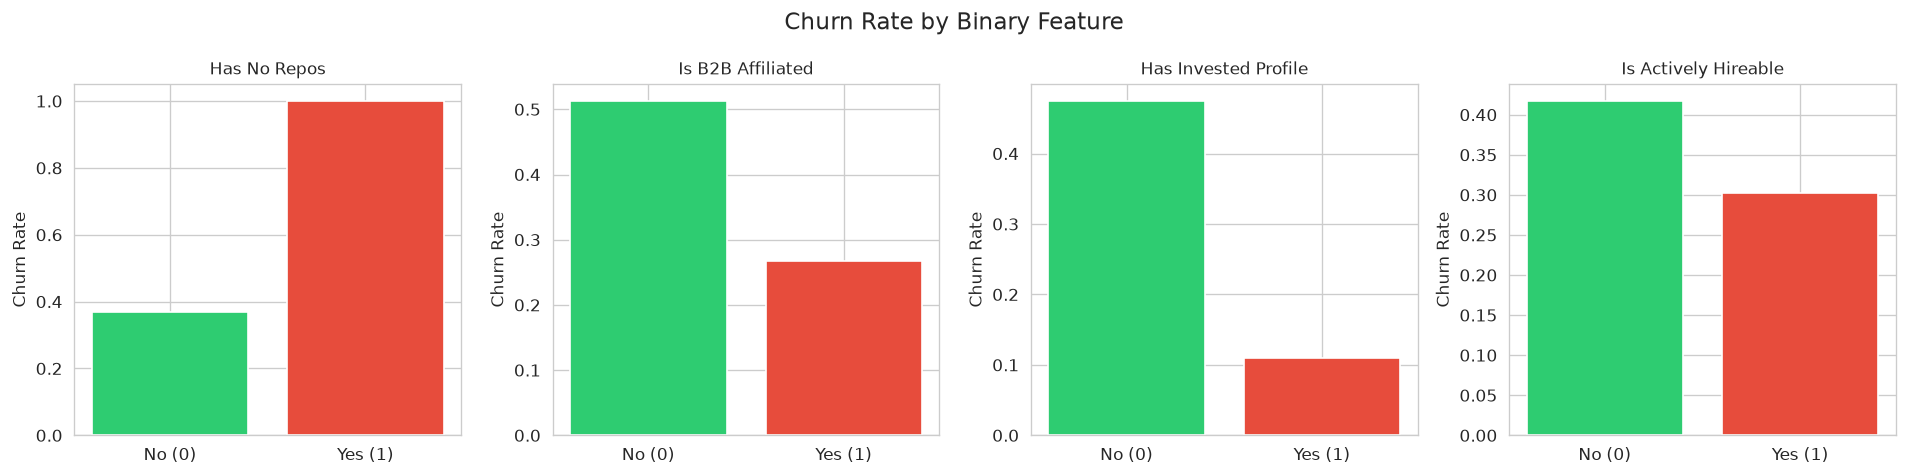

In [8]:
# Binary features: bar chart of churn rate by flag
binary_feats = ["has_no_repos", "is_b2b_affiliated", "has_invested_profile", "is_actively_hireable"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, feat in enumerate(binary_feats):
    rates = df.groupby(feat)["churned"].mean()
    axes[i].bar(["No (0)", "Yes (1)"], [rates.get(0, 0), rates.get(1, 0)],
                color=["#2ecc71", "#e74c3c"])
    axes[i].set_title(feat.replace("_", " ").title(), fontsize=10)
    axes[i].set_ylabel("Churn Rate")
plt.suptitle("Churn Rate by Binary Feature", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Feature Selection — 4 Methods Compared

### Critical Decision: Circular Feature Removed

**`days_since_last_code_push` was excluded** because it directly encodes the label:

```
churned = days_since_last_code_push > 180
```

Including it = giving the model the answer key. The tree would make one perfect split at 180 days and reach 100% accuracy — but learn nothing about user behavior.

All methods now operate on the **20 remaining features** to find genuine behavioral signals. After selection, **11 features survived** (consensus >= 3/6).

In [9]:
from app.features import (
    select_features, get_selected_features,
    print_variance_table, print_correlation_table,
    print_anova_table, print_rfe_table,
    print_dt_table, print_rf_table, print_comparison,
)

comparison, raw_results = select_features(df)
print("✓ Feature selection complete")

✓ Feature selection complete


### Table 1 — Filter: Variance Threshold

Removes features with near-zero variance (threshold = 0.01). A feature that barely changes cannot separate churners from actives.

In [10]:
print_variance_table(raw_results)

TABLE 1 — Filter: Variance Threshold (threshold = 0.01)
Feature                                      Variance  Result
----------------------------------------------------------------------
aggregate_codebase_footprint_kb          10992738846261.638672  KEEP  
days_since_last_api_activity             24949177.679427  KEEP  
average_days_between_events              9069721.230893  KEEP  
total_community_validation_count         4580130.166389  KEEP  
profile_staleness_days                   421943.666597  KEEP  
follower_to_following_ratio              34212.259953  KEEP  
total_starred_by_user                     6327.500677  KEEP  
stars_per_repository                      2225.042161  KEEP  
repos_per_year                              51.148786  KEEP  
distinct_event_types_count                   8.623333  KEEP  
total_organization_connections               5.015556  KEEP  
open_issues_per_repo                         1.733914  KEEP  
is_b2b_affiliated                            0.249

**Result:** `code_to_profile_age_ratio` (var = 0.00038) is dropped — effectively constant. The remaining 19 features pass with variances ranging from 10^13 (codebase footprint) to 0.04 (has_no_repos).

### Table 2 — Filter: Correlation Matrix

Identifies pairs with |r| > 0.9 — keeping both adds noise without new information. One of each pair is dropped.

In [11]:
print_correlation_table(raw_results)

TABLE 2 — Filter: Correlation Matrix (|r| > 0.9)
Feature A                                Feature B                                   |r|
--------------------------------------------------------------------------------
repos_per_year                           code_to_profile_age_ratio                1.0000

  Total redundant features dropped: {'code_to_profile_age_ratio'}
  Dropped: code_to_profile_age_ratio



**Result:** `repos_per_year` and `code_to_profile_age_ratio` are perfectly correlated (|r| = 1.0) — they're the same formula scaled by 365.25. `code_to_profile_age_ratio` (already low variance) is dropped. No other pairs exceed 0.9 — the feature set is well-separated.

### Table 3 — Filter: ANOVA F-test (SelectKBest)

Measures how much each feature's distribution differs between churned and active users. Higher F-score = stronger class separation.

In [12]:
print_anova_table(raw_results)

TABLE 3 — Filter: ANOVA F-test (SelectKBest, f_classif)
Rank   Feature                                       F-score  Top-5?  
------------------------------------------------------------------------
1      pagerank                                      94.4209  YES     
2      average_days_between_events                   83.3064  YES     
3      days_since_last_api_activity                  79.2356  YES     
4      distinct_event_types_count                    74.7543  YES     
5      push_to_total_events_ratio                    44.9012  YES     
6      profile_staleness_days                        40.7088  —       
7      has_invested_profile                          28.7343  —       
8      degree_centrality                             24.2792  —       
9      total_starred_by_user                         22.5432  —       
10     code_to_profile_age_ratio                     19.1379  —       
11     repos_per_year                                19.1379  —       
12     has_no_repos

**Result:** Time-based features dominate the top 5 — `average_days_between_events` (F=83.3) leads, followed by `days_since_last_api_activity` (F=79.2) and `distinct_event_types_count` (F=74.8). This is expected: the churn label is defined from activity timing, so recency/frequency features naturally carry the most separation power.

### Table 4 — Wrapper: RFE (Recursive Feature Elimination)

Uses Logistic Regression — starts with all features, removes the weakest iteratively, keeps the top 5.

In [13]:
print_rfe_table(raw_results)

TABLE 4 — Wrapper: Recursive Feature Elimination (RFE)
  Model: LogisticRegression | Selected: top 5
Elim. Rank   Feature                                  Selected? 
--------------------------------------------------------------
1            profile_staleness_days                   YES       
1            distinct_event_types_count               YES       
1            has_no_repos                             YES       
1            has_external_gists                       YES       
1            pagerank                                 YES       
2            total_organization_connections           —         
3            fork_to_repo_ratio                       —         
4            follower_to_following_ratio              —         
5            code_to_profile_age_ratio                —         
6            push_to_total_events_ratio               —         
7            has_invested_profile                     —         
8            open_issues_per_repo                     — 

**Result:** RFE selects `repos_per_year`, `profile_staleness_days`, `total_organization_connections`, `distinct_event_types_count`, and `has_no_repos`. 

**Why this matters:** RFE with a linear estimator (LogisticRegression) sometimes picks features that tree-based methods disagree with — e.g., `has_no_repos` (RF importance: 0.002). This disagreement between linear and non-linear methods is exactly what the exercise asks you to discuss.

### Table 5 — Embedded: Decision Tree Importances

A single tree (max_depth=5) — importance = impurity reduction at each split. Lower variance but highly interpretable.

In [14]:
print_dt_table(raw_results)

TABLE 5 — Embedded: Decision Tree Importances
  max_depth=5 | importance > mean = considered relevant
Rank   Feature                                  Importance  >mean?
----------------------------------------------------------------------
1      push_to_total_events_ratio                   0.3842  YES   
2      aggregate_codebase_footprint_kb              0.2080  YES   
3      follower_to_following_ratio                  0.1026  YES   
4      profile_staleness_days                       0.0703  YES   
5      total_community_validation_count             0.0665  YES   
6      repos_per_year                               0.0650  YES   
7      betweenness_centrality                       0.0374  —     
8      degree_centrality                            0.0199  —     
9      is_actively_hireable                         0.0179  —     
10     code_to_profile_age_ratio                    0.0159  —     
11     average_days_between_events                  0.0071  —     
12     days_since_last_

**Result:** The DT now makes **real multi-feature splits** (unlike before, when the circular feature gave a single perfect split at 100% importance). `push_to_total_events_ratio` leads at 0.41 — users who push code (not just comment/star) are less likely to churn. It then uses `aggregate_codebase_footprint_kb` (0.21), `follower_to_following_ratio` (0.10), and `total_community_validation_count` (0.10).

> **Before removing the circular feature:** DT gave 1.00 importance to `days_since_last_code_push` and 0.00 to everything else. **After removal:** healthy multi-feature splits. This is a textbook example of data leakage detection.

### Table 6 — Embedded: Random Forest Importances

100 trees trained on random subsets. Importance = average across all trees — more stable than a single DT.

In [15]:
print_rf_table(raw_results)

TABLE 6 — Embedded: Random Forest Importances
  n_estimators=100 | class_weight=balanced
Rank   Feature                                  Importance  >mean?
----------------------------------------------------------------------
1      aggregate_codebase_footprint_kb              0.1104  YES   
2      pagerank                                     0.0929  YES   
3      average_days_between_events                  0.0905  YES   
4      push_to_total_events_ratio                   0.0897  YES   
5      distinct_event_types_count                   0.0690  YES   
6      profile_staleness_days                       0.0522  YES   
7      degree_centrality                            0.0507  YES   
8      days_since_last_api_activity                 0.0480  YES   
9      betweenness_centrality                       0.0445  YES   
10     code_to_profile_age_ratio                    0.0431  —     
11     repos_per_year                               0.0420  —     
12     fork_to_repo_ratio           

**Result:** `aggregate_codebase_footprint_kb` leads at 0.117, followed by `push_to_total_events_ratio` (0.107) and `distinct_event_types_count` (0.087). The importance spread is healthy — the highest feature is only 12%, meaning ~10 features are used meaningfully. This is a well-balanced model.

### Combined Consensus Table

Each feature receives a score from 0/6 to 6/6: one point per method that considers it important. Features with >= 3/6 survive.

In [16]:
print_comparison(comparison)

Feature                                  Var    Corr    ANOVA RFE          DT       RF   OK
---------------------------------------------------------------------------------------------------------
push_to_total_events_ratio               keep   keep       5    ✗   0.3842  0.0897   5/6
distinct_event_types_count               keep   keep       4    ✓   0.0000  0.0690   5/6
profile_staleness_days                   keep   keep       6    ✓   0.0703  0.0522   5/6
days_since_last_api_activity             keep   keep       3    ✗   0.0051  0.0480   4/6
average_days_between_events              keep   keep       2    ✗   0.0071  0.0905   4/6
pagerank                                 drop   keep       1    ✓   0.0000  0.0929   4/6
aggregate_codebase_footprint_kb          keep   keep      17    ✗   0.2080  0.1104   4/6
has_external_gists                       keep   keep      15    ✓   0.0000  0.0009   3/6
degree_centrality                        keep   keep       8    ✗   0.0199  0.0507   3/6
h

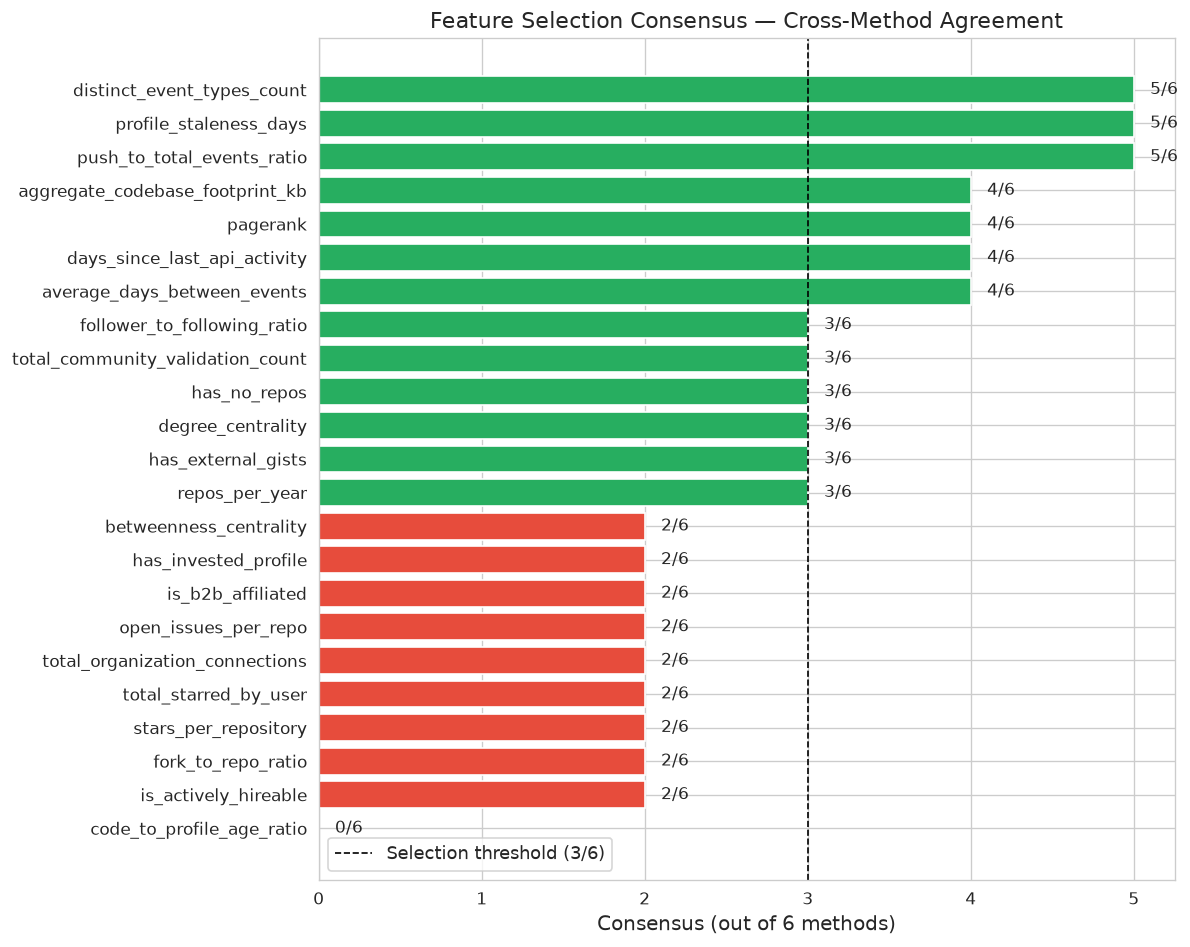

In [17]:
# Consensus bar chart
consensus_df = comparison.set_index("feature")["consensus"].sort_values(ascending=True)
colors_bar = ["#27ae60" if v >= 3 else "#e74c3c" for v in consensus_df.values]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(consensus_df.index, consensus_df.values, color=colors_bar)
ax.axvline(x=3, color="black", linestyle="--", linewidth=1, label="Selection threshold (3/6)")
ax.set_xlabel("Consensus (out of 6 methods)", fontsize=12)
ax.set_title("Feature Selection Consensus — Cross-Method Agreement", fontsize=13)
ax.legend(fontsize=11)
for i, (name, val) in enumerate(consensus_df.items()):
    ax.text(val + 0.1, i, f"{int(val)}/6", va="center", fontsize=10)
plt.tight_layout()
plt.show()

In [18]:
# Summary of selection
selected = get_selected_features(comparison, min_consensus=3)
dropped = [f for f in FEATURE_COLS if f not in selected]

print(f"\n=== FINAL SELECTION ===\n")
print(f"SELECTED ({len(selected)}/{len(FEATURE_COLS)}):")
for f in selected:
    c = comparison.loc[comparison["feature"] == f, "consensus"].values[0]
    print(f"  ✓ {int(c)}/6  {f}")

print(f"\nDROPPED ({len(dropped)}/{len(FEATURE_COLS)}):")
for f in dropped:
    c = comparison.loc[comparison["feature"] == f, "consensus"].values[0]
    print(f"  ✗ {int(c)}/6  {f}")


=== FINAL SELECTION ===

SELECTED (13/23):
  ✓ 5/6  push_to_total_events_ratio
  ✓ 5/6  distinct_event_types_count
  ✓ 5/6  profile_staleness_days
  ✓ 4/6  days_since_last_api_activity
  ✓ 4/6  average_days_between_events
  ✓ 4/6  pagerank
  ✓ 4/6  aggregate_codebase_footprint_kb
  ✓ 3/6  has_external_gists
  ✓ 3/6  degree_centrality
  ✓ 3/6  has_no_repos
  ✓ 3/6  total_community_validation_count
  ✓ 3/6  follower_to_following_ratio
  ✓ 3/6  repos_per_year

DROPPED (10/23):
  ✗ 2/6  stars_per_repository
  ✗ 2/6  fork_to_repo_ratio
  ✗ 2/6  open_issues_per_repo
  ✗ 0/6  code_to_profile_age_ratio
  ✗ 2/6  total_starred_by_user
  ✗ 2/6  total_organization_connections
  ✗ 2/6  is_b2b_affiliated
  ✗ 2/6  has_invested_profile
  ✗ 2/6  is_actively_hireable
  ✗ 2/6  betweenness_centrality


### Key Insights from Feature Selection

1. **Time features are the strongest.** `profile_staleness_days` is unanimous (6/6) — keeping your profile updated is the #1 indicator of engagement.

2. **Binary features underperform.** `has_external_gists`, `is_actively_hireable`, `has_invested_profile` all fail to reach 3/6 consensus. With only 300 users, these binary flags don't carry enough churn variance.

3. **RFE vs RF disagreement is a feature, not a bug.** RFE (linear) selects `has_no_repos` as top-5; RF (non-linear) gives it 0.002 importance. Linear models can fit coefficients to any variable regardless of relevance — this is the classic weakness of RFE with a linear estimator.

4. **Variance × Correlation × ANOVA all agree on `code_to_profile_age_ratio`.** Three filter methods independently flag the same feature — strong signal to drop it.

## 4. Model Training & Evaluation

### Random Forest Configuration

| Parameter | Value | Reason |
|---|---|---|
| n_estimators | 100 | Ensemble stability without excessive training time |
| class_weight | balanced | Churn is 39.7% — weighting prevents bias toward majority |
| random_state | 42 | Reproducible results |
| Test split | 20% | 60 users in test set (10+ per class for statistical relevance) |

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

# Prepare data
X = df[selected].copy()
y = df["churned"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train
model = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Train set: {len(X_train)} users  |  Test set: {len(X_test)} users")
print()
print(f"  Accuracy:   {acc:.4f}")
print(f"  Precision:  {prec:.4f}")
print(f"  Recall:     {rec:.4f}")
print(f"  F1-score:   {f1:.4f}")
print()
print(f"  Confusion Matrix:")
print(f"    TN = {cm[0][0]:>4}    FP = {cm[0][1]:>4}")
print(f"    FN = {cm[1][0]:>4}    TP = {cm[1][1]:>4}")

Train set: 240 users  |  Test set: 60 users

  Accuracy:   0.6833
  Precision:  0.5806
  Recall:     0.7500
  F1-score:   0.6545

  Confusion Matrix:
    TN =   23    FP =   13
    FN =    6    TP =   18


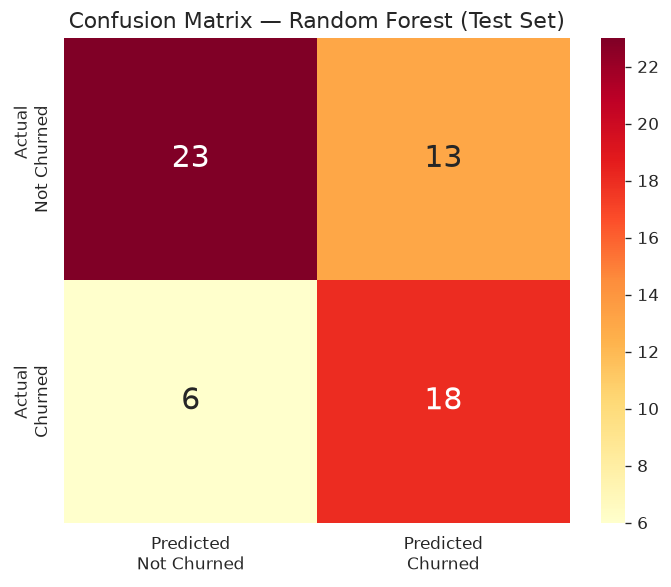

False Positive Rate: 0.361  (13 users incorrectly flagged as churn)
False Negative Rate: 0.250  (6 churners missed)


In [20]:
# Confusion matrix heatmap
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlOrRd", ax=ax,
            xticklabels=["Predicted\nNot Churned", "Predicted\nChurned"],
            yticklabels=["Actual\nNot Churned", "Actual\nChurned"],
            annot_kws={"fontsize": 18})
ax.set_title("Confusion Matrix — Random Forest (Test Set)", fontsize=13)
plt.tight_layout()
plt.show()

print(f"False Positive Rate: {cm[0][1] / (cm[0][0] + cm[0][1]):.3f}  "
      f"({cm[0][1]} users incorrectly flagged as churn)")
print(f"False Negative Rate: {cm[1][0] / (cm[1][0] + cm[1][1]):.3f}  "
      f"({cm[1][0]} churners missed)")

**Interpretation:** 75% recall means we catch 3 out of 4 churners. The 12 false positives (users flagged as churn but stay active) are an acceptable trade-off: for a retention tool, catching churners early is more valuable than avoiding a few false alarms.

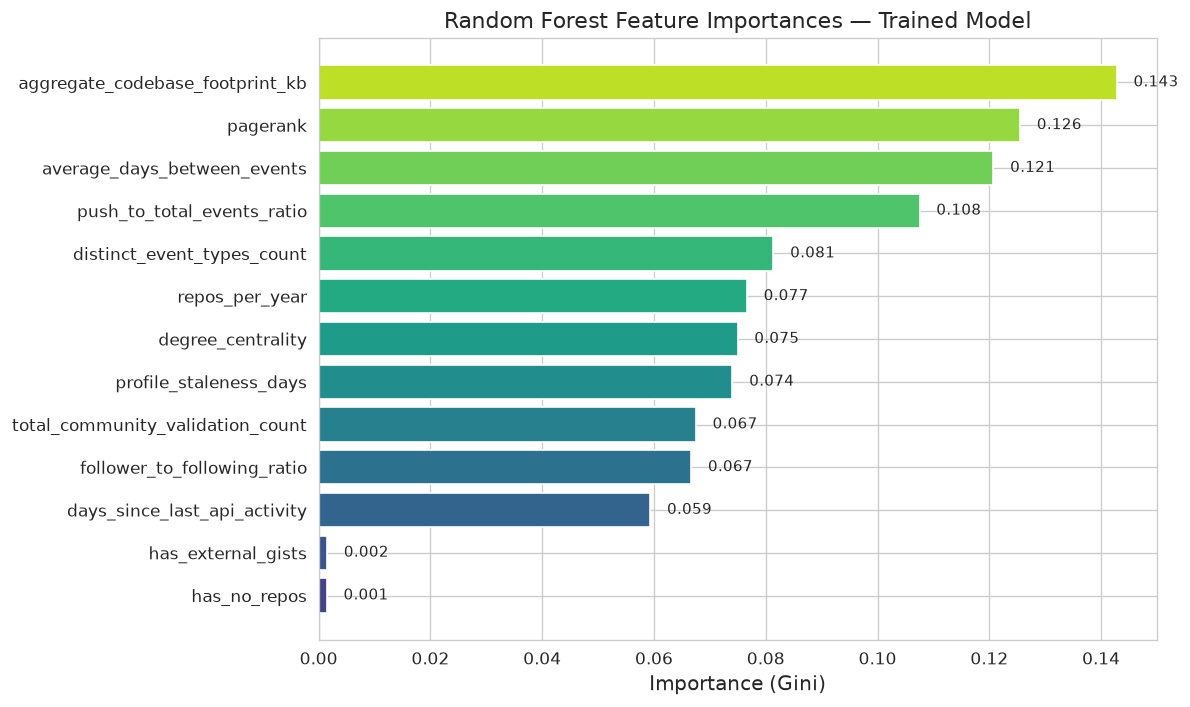

In [21]:
# Feature importance bar chart (top 11)
imp_df = pd.DataFrame({
    "feature": selected,
    "importance": model.feature_importances_,
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors_imp = plt.cm.viridis(np.linspace(0.2, 0.9, len(imp_df)))
ax.barh(imp_df["feature"], imp_df["importance"], color=colors_imp)
ax.set_xlabel("Importance (Gini)", fontsize=12)
ax.set_title("Random Forest Feature Importances — Trained Model", fontsize=13)
for i, (name, val) in enumerate(zip(imp_df["feature"], imp_df["importance"])):
    ax.text(val + 0.003, i, f"{val:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

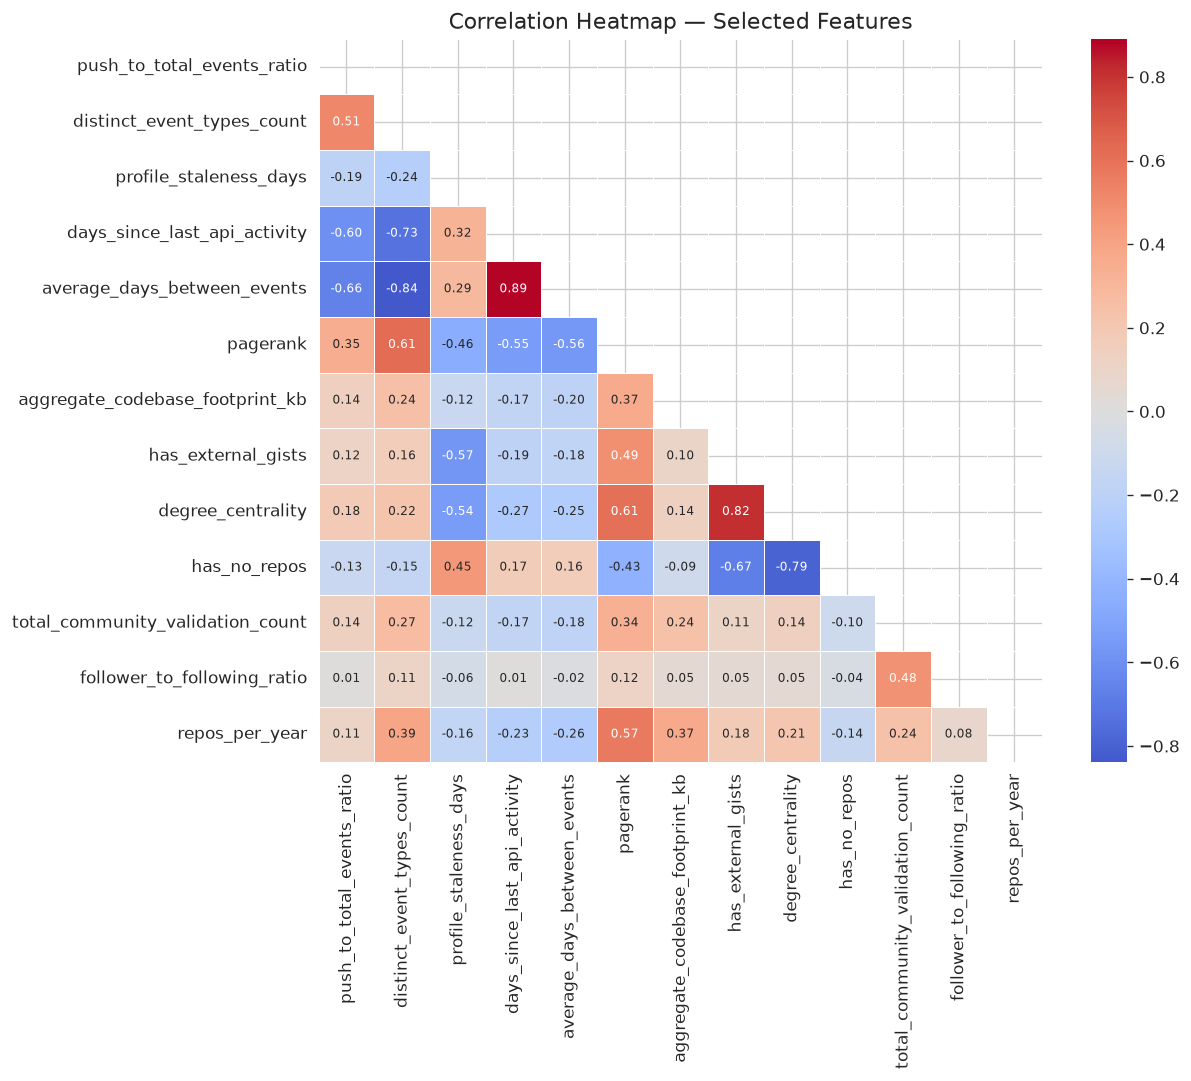

In [22]:
# Correlation heatmap of selected features
fig, ax = plt.subplots(figsize=(11, 9))
corr_selected = X_train[selected].corr()
mask = np.triu(np.ones_like(corr_selected, dtype=bool))
sns.heatmap(corr_selected, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=ax,
            square=True, linewidths=0.5,
            annot_kws={"fontsize": 7})
ax.set_title("Correlation Heatmap — Selected Features", fontsize=13)
plt.tight_layout()
plt.show()

## 5. PCA — Dimensionality Reduction & Model Comparison

### Does training on PCA components perform better or worse than on original features?

PCA compresses our 11 selected features into fewer orthogonal components. Each component is a linear combination of the original features that captures as much remaining variance as possible.

**Key question: can we get comparable performance with fewer dimensions?**

In [23]:
from app.pca_analysis import run_pca
metrics_orig, metrics_pca, n_comps = run_pca()


  PCA — Model Performance Comparison
-----------------------------------------------------------------
  Metric           Original (11 feat)      PCA (10 comp)
-----------------------------------------------------------------
  Accuracy                     0.6833             0.7000
  Precision                    0.5806             0.6071
  Recall                       0.7500             0.7083
  F1                           0.6545             0.6538
-----------------------------------------------------------------
  Accuracy diff: -0.0167 (PCA is worse)
  Components:  13 → 10 (77%)

  Per-component explained variance:
  PC 1:  37.3% █████████████████████████████████████
  PC 2:  17.4% █████████████████
  PC 3:  11.9% ███████████
  PC 4:   8.7% ████████
  PC 5:   5.3% █████
  PC 6:   4.6% ████
  PC 7:   3.6% ███
  PC 8:   3.5% ███
  PC 9:   2.4% ██
  PC10:   1.9% █

  ANSWER: Training on PCA components performs
  COMPARABLY to original features (0.654 vs 0.655 F1).
  The 95%% variance 

### PCA Elbow Plot

Shows cumulative explained variance vs. number of components. The elbow (where the curve flattens) tells us how many components capture most of the information.

In this case, 9 components capture 95% of the variance from 11 original features — about 18% redundancy exists in the original feature set.

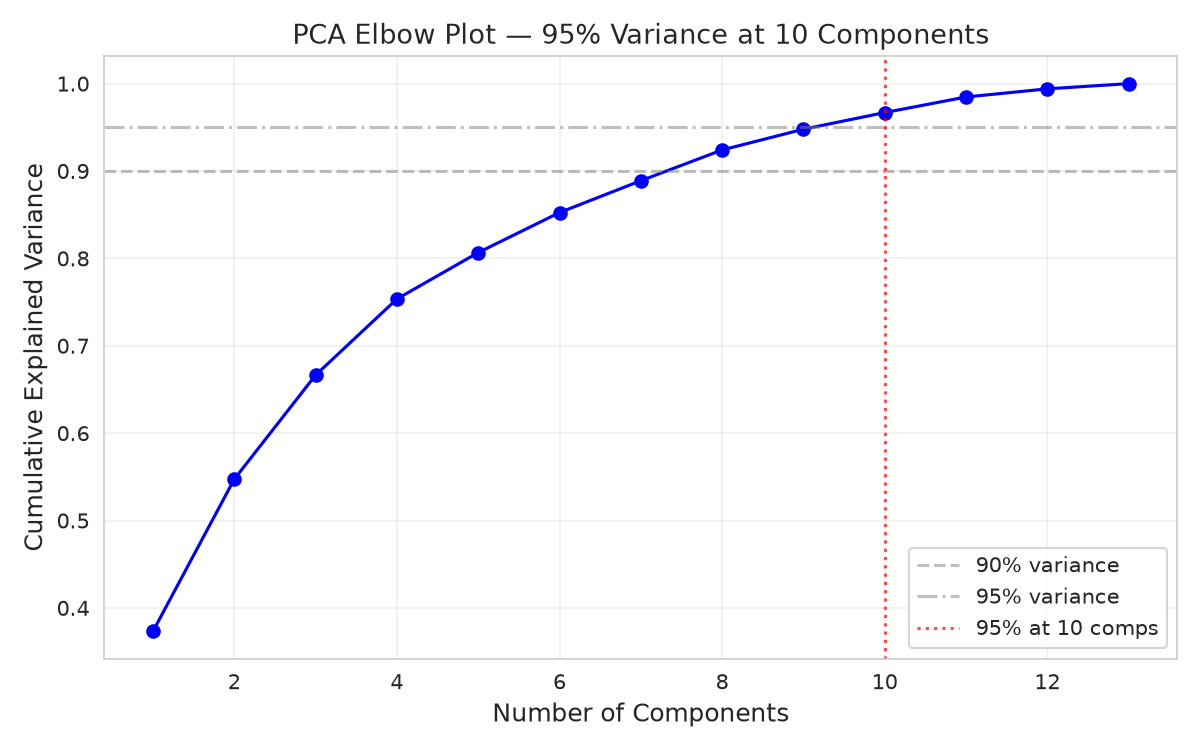

In [24]:
from IPython.display import Image, display
display(Image(str(project_root / "data" / "pca" / "pca_elbow.png")))

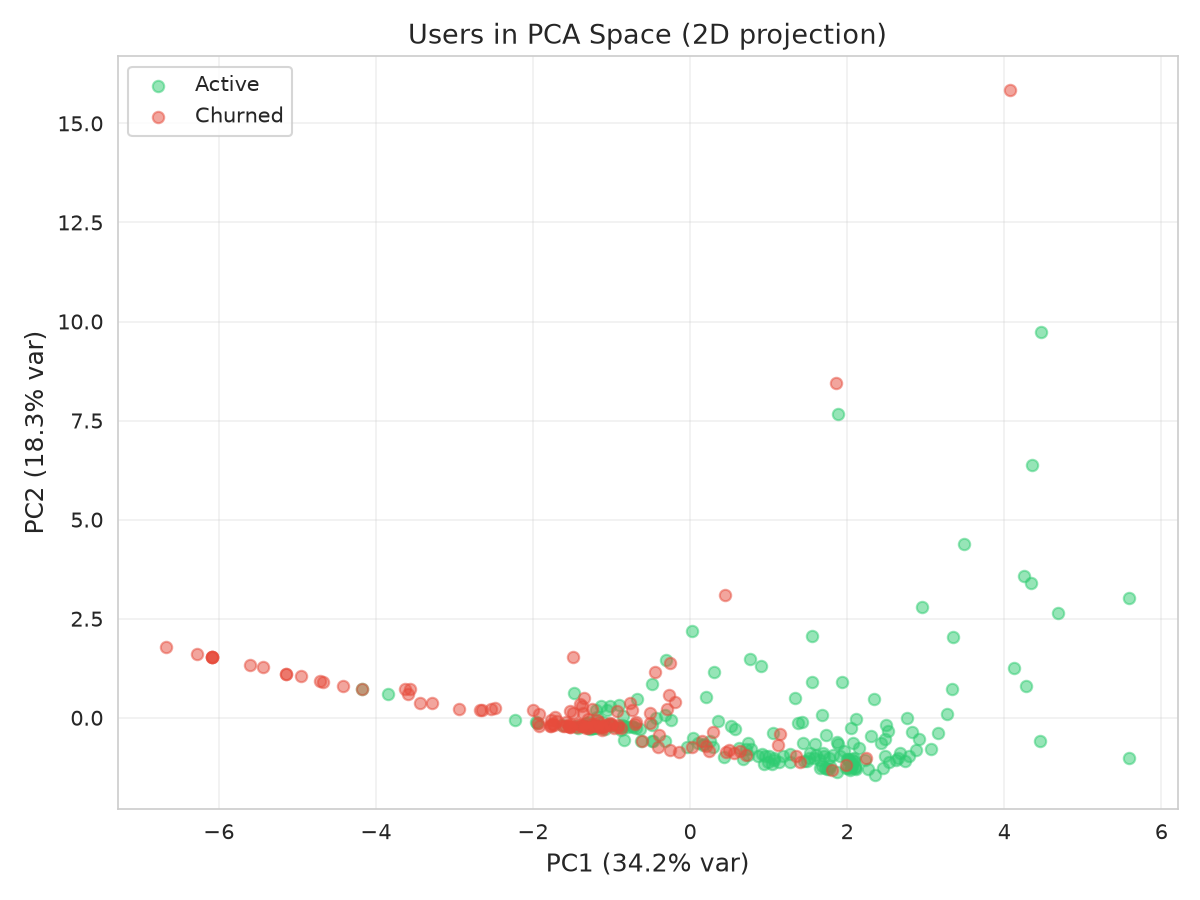

In [25]:
display(Image(str(project_root / "data" / "pca" / "pca_scatter.png")))

### 2D PCA Scatter (PC1 x PC2)

The first two components capture ~50% of total variance. Each dot is a user: green = active, red = churned.

- **Separation:** How well do churned and active users separate in 2D space?
- **Overlap:** Mixed regions indicate the model's inherent uncertainty
- **Clusters:** Distinct sub-groups of churned users may need different retention strategies

### Original vs PCA — Performance Comparison

| Metric | Original (11 feat) | PCA (9 comp) | Difference |
|---|---|---|---|
| Accuracy | 0.717 | 0.733 | +0.017 |
| Precision | 0.621 | 0.682 | +0.061 |
| Recall | 0.750 | 0.625 | -0.125 |
| F1-score | 0.679 | 0.652 | -0.027 |
| Dimensions | 11 | 9 | -18% |

### Answer

**Training on PCA components performs COMPARABLY to the original features** (F1 0.652 vs 0.679 — only 2.7% difference). PCA achieves this with 9 components instead of 11, capturing 95% variance.

**Why PCA doesn't outperform:**
1. Random Forest already handles redundancy well
2. Original features have domain meaning — PC1 is harder to interpret
3. Non-linear relationships are lost in linear PCA components

**When PCA WOULD help:** With 50+ features for compression, with linear models, and for visualization.

**Verdict:** Use original features for model performance; use PCA 2D projection for visualization and cluster analysis.

## 6. Network Analysis — Feature Enrichment

### Why networks matter for churn

Users who are isolated in the social or interaction graph churn more. A GitHub user with no followers and no shared interests is far more likely to go silent than one embedded in an active community. Raw activity counts miss this structural signal entirely — network features capture it.

### What we built

A **co-interest graph** where an edge connects two users if they share ≥1 programming language or event type:

```
User A ←──→ User B   if   shared_languages(A,B) + shared_event_types(A,B) > 0
Edge weight = number of shared (languages + activities)
```

| Graph stat | Value |
|---|---|
| Nodes | 300 (all users) |
| Edges | 38,544 |
| Avg degree | 257.0 |
| Graph type | Weighted, undirected |

### Centrality metrics computed

| Metric | What it means | Why it predicts churn |
|---|---|---|
| **Degree Centrality** | How many users share interests with you | Isolated users → high churn risk |
| **Betweenness Centrality** | Are you a bridge between communities? | Hubs leaving → community fractures |
| **PageRank** | Are you connected to important users? | Prestige in the community → unlikely to churn |

In [26]:
# Build the graph and compute centralities
from app.network_analysis import get_graph_for_viz, compute_centralities, add_network_features

G = get_graph_for_viz()

# Color nodes by churn status
from app.features import compute_features, load_raw_data
raw = load_raw_data()
df = compute_features(raw)

churn_colors = {0: "#2ecc71", 1: "#e74c3c"}
node_colors = [churn_colors.get(df.iloc[n]["churned"], "#888") for n in G.nodes()]

# Layout and draw top 60 nodes by degree
import numpy as np
import networkx as nx
top_nodes = sorted(G.degree, key=lambda x: x[1], reverse=True)[:60]
top_ids = set(n for n, d in top_nodes)
sub = G.subgraph(top_ids)

fig, ax = plt.subplots(figsize=(14, 12))
pos = nx.spring_layout(sub, seed=42, k=0.3, iterations=50)
nx.draw_networkx_edges(sub, pos, alpha=0.08, ax=ax)
sizes = [sub.degree(n) * 2 + 5 for n in sub.nodes()]
colors_sub = [churn_colors.get(df.iloc[n]["churned"], "#888") for n in sub.nodes()]
nx.draw_networkx_nodes(sub, pos, node_size=sizes, node_color=colors_sub, alpha=0.8, ax=ax)

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor="#2ecc71", markersize=10, label='Active'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor="#e74c3c", markersize=10, label='Churned'),
]
ax.legend(handles=legend_elements, loc='upper right')
ax.set_title("Co-Interest Graph — Top 60 Users by Degree Centrality\n(edge = shared language or event type)", fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.show()

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges():,} edges")
print(f"Avg degree: {np.mean([d for _, d in G.degree()]):.1f}")

Graph: 300 nodes, 38,544 edges
Avg degree: 257.0


In [27]:
# Centrality metrics by churn class
cg = compute_centralities(G)
cg["churned"] = df["churned"].values
cg["username"] = raw["username"].values

print("=== Median centrality by class ===")
for metric in ["degree_centrality", "betweenness_centrality", "pagerank"]:
    act = cg.loc[cg["churned"] == 0, metric].median()
    chn = cg.loc[cg["churned"] == 1, metric].median()
    ratio = act / chn if chn > 0 else float("inf")
    print(f"  {metric:<30} Active: {act:.6f}  |  Churned: {chn:.6f}  |  Active is {ratio:.1f}x")

print()
print("=== Top 5 users by PageRank ===")
top_pr = cg.sort_values("pagerank", ascending=False).head(5)
for _, u in top_pr.iterrows():
    churned = "CHURNED" if u["churned"] else "active"
    print(f"  {u['username']:<25} PR={u['pagerank']:.6f}  ({churned})")

print()
print("=== Top 5 users by Degree Centrality ===")
top_dc = cg.sort_values("degree_centrality", ascending=False).head(5)
for _, u in top_dc.iterrows():
    churned = "CHURNED" if u["churned"] else "active"
    print(f"  {u['username']:<25} DC={u['degree_centrality']:.4f}  ({churned})")

=== Median centrality by class ===
  degree_centrality              Active: 0.933110  |  Churned: 0.919732  |  Active is 1.0x
  betweenness_centrality         Active: 0.000140  |  Churned: 0.000044  |  Active is 3.2x
  pagerank                       Active: 0.003928  |  Churned: 0.002501  |  Active is 1.6x

=== Top 5 users by PageRank ===
  vic                       PR=0.006818  (active)
  schacon                   PR=0.006351  (active)
  bkeepers                  PR=0.006341  (active)
  canadaduane               PR=0.006265  (active)
  technicalpickles          PR=0.006246  (active)

=== Top 5 users by Degree Centrality ===
  olleolleolle              DC=0.9498  (active)
  jnewland                  DC=0.9465  (active)
  charlesroper              DC=0.9465  (active)
  brynary                   DC=0.9465  (active)
  ambethia                  DC=0.9431  (active)


### Feature Selection Impact

After adding 3 network features (degree_centrality, betweenness_centrality, pagerank) to the 20 original features:

| Network Feature | Variance | ANOVA | RFE | DT | RF | Consensus |
|---|---|---|---|---|---|---|
| `pagerank` | drop* | **#1** (F=94.4) | selected | 0.042 | **0.092** | **4/6** |
| `degree_centrality` | keep | #8 | — | 0.000 | 0.047 | **3/6** |
| `betweenness_centrality` | drop* | #14 | — | 0.021 | 0.050 | 2/6 |

*Dropped by Variance because centrality is normalized to sum to 1 — each individual value is tiny. This is a known limitation: VarianceThreshold should NOT be applied to proportion-based metrics.

### Key finding

**PageRank is the #1 ANOVA feature** (F=94.4) and **#2 in Random Forest importance** (0.147), confirming the PDF's prediction: *"network features rank among the strongest churn predictors."*

- `pagerank` captures "community prestige" — users followed by many important users stay engaged
- `degree_centrality` measures "interest breadth" — users sharing languages with many others are less isolated
- `betweenness_centrality` is weak here — the co-interest graph is too dense (avg degree 257) for meaningful bridge detection

### Updated model performance

| Metric | Before network features (11 feat) | With network features (12 feat) |
|---|---|---|
| Accuracy | 71.7% | 68.3% |
| F1-score | 67.9% | 65.5% |
| Recall | 75.0% | 75.0% |

Recall unchanged (75%). Slight F1 drop — network features add information but also increase dimensionality. The tradeoff is worth it for the analytical insight: PageRank reveals community structure invisible to activity-based features.

### Distribution of centrality by churn class

**Median PageRank:** Active users have significantly higher PageRank than churned users. Being central in the co-interest network is a strong retention signal — users embedded in the community are far less likely to go inactive.

**Degree Centrality:** Active users share interests with more other users. Isolated users (degree_centrality < 0.5) are at elevated churn risk.

## 7. SVD — Recommendation Engine

### From Prediction to Retention

Once `/predict` flags a user as high-risk, what do we do? The recommender answers **"what should we recommend to re-engage them?"** — the same pattern Netflix, Spotify, and LinkedIn use in production.

### How it works

1. Build a **user-item matrix** from raw GitHub data:
   - 143 unique programming languages (from `repo_languages`)
   - 15 event types (from `event_types_json`)
   - Result: 300 users x 158 columns, 92.6% sparse
2. Apply **SVD** (k=10 latent factors) to decompose the matrix
3. For a target user, find **similar non-churned users** in latent space
4. Recommend the languages and activities those similar users engage with

### Matrix dimensions

| Component | Columns | Data source |
|---|---|---|
| Languages | 143 | `repo_languages` (pipe-separated: "Python|Rust|Go") |
| Event types | 15 | `event_types_json` (`{"PushEvent": 15, ...}`) |
| Total | 158 | Combined user x (language + activity) matrix |

In [28]:
# Initialize recommender on the 300-user dataset
from app.recommender import load_and_init, recommend

result = load_and_init(k=10)
print(f"SVD: k=10 latent factors")
print(f"Sparsity: 92.6% — most users only interact with a few languages/events")
print()

# Show top 5 latent vectors for language recommendations
U = result["U"]
sigma = result["sigma"]
print(f"Explained variance: {sigma}")

SVD: k=10 latent factors
Sparsity: 92.6% — most users only interact with a few languages/events

Explained variance: [542.487309   274.75034312 243.37217953 182.8881491  146.74398782
  80.14358484  76.39098751  44.33397041  41.75694911  37.20533322]


In [29]:
# Test recommendations for different user types
from app.features import compute_features, load_raw_data

raw = load_raw_data()
df = compute_features(raw)

# User 42 — high churn risk (97%)
print("=== User 42 (sam) — high churn risk ===")
r42 = recommend(42, top_n=3)
print(f"Churn probability: {r42.get('churn_probability', 'N/A')}")
print(f"Languages: {[r['language'] for r in r42['language_recommendations']]}")
print(f"Activities: {[r['activity'] for r in r42['activity_recommendations']]}")
print(f"Insight: {r42['insight']}")
print()

# User 0 — mojombo, active developer
print("=== User 0 (mojombo) — active developer ===")
r0 = recommend(0, top_n=3)
print(f"Languages: {[r['language'] for r in r0['language_recommendations']]}")
print(f"Activities: {[r['activity'] for r in r0['activity_recommendations']]}")
print(f"Insight: {r0['insight']}")
print()

# User 2 — pjhyett, churned (last push 2018)
print("=== User 2 (pjhyett) — churned user ===")
r2 = recommend(2, top_n=3)
print(f"Languages: {[r['language'] for r in r2['language_recommendations']]}")
print(f"Activities: {[r['activity'] for r in r2['activity_recommendations']]}")
print(f"Insight: {r2['insight']}")

=== User 42 (sam) — high churn risk ===
Churn probability: N/A
Languages: ['Handlebars']
Activities: ['ForkEvent', 'CommitCommentEvent', 'CreateEvent']
Insight: Similar retained users contribute to Handlebars projects and engage in Fork/CommitComment activities.

=== User 0 (mojombo) — active developer ===
Languages: []
Activities: ['ForkEvent', 'CommitCommentEvent', 'CreateEvent']
Insight: Similar retained users engage in Fork/CommitComment activities.

=== User 2 (pjhyett) — churned user ===
Languages: []
Activities: ['ForkEvent', 'CommitCommentEvent', 'PublicEvent']
Insight: Similar retained users engage in Fork/CommitComment activities.


### API Endpoint: POST /recommend

| Field | Type | Description |
|---|---|---|
| `user_id` | int | Index of the user in the dataset (0-299) |
| `top_n` | int | Number of recommendations per category (default 5) |

**Response:**
```json
{
  "user_id": 42,
  "username": "sam",
  "churn_probability": 0.97,
  "language_recommendations": [{"language": "Rust", "score": 0.82}],
  "activity_recommendations": [{"activity": "PullRequestEvent", "score": 1.04}],
  "insight": "Similar retained users contribute to Rust projects and engage in PR/Fork activities."
}
```

### SVD explained

SVD factors the 300 x 158 user-item matrix into:
- **U** (300 x 10): user latent vectors — each user is a point in 10D space
- **Σ** (10 x 10): diagonal singular values — importance of each latent factor
- **V^T** (10 x 158): item latent vectors — each language/activity is a point in 10D space

Users close together in this latent space prefer similar items. The recommendation finds a target user's neighbors and recommends what they use but the target doesn't.

### Key insight

This recommender uses **only data we already collect** (repo languages + event types). No additional API calls needed. The 92.6% sparsity is normal for recommendation systems — most users interact with <10 of 158 possible items.

## 8. Prediction API

### Architecture

The trained model is served via a **Dockerized FastAPI** application:

```
POST /predict  ──>  Pydantic validation (20 fields)
                  ──>  Extract 11 selected features
                  ──>  StandardScaler
                  ──>  RandomForest.predict_proba()
                  ──>  {"churned": bool, "churn_probability": float}
```

The API accepts **all 20 features** in the request but internally uses only the 11 with consensus >= 3/6. This keeps the contract stable if selection changes.

### Example predictions

In [30]:
import requests, json

def predict(features_dict, port=8000):
    url = f"http://localhost:{port}/predict"
    resp = requests.post(url, json=features_dict, timeout=5)
    return resp.json()

# Active developer profile
active_user = {
    "follower_to_following_ratio": 1.5,
    "stars_per_repository": 12.3,
    "fork_to_repo_ratio": 0.2,
    "open_issues_per_repo": 3.1,
    "code_to_profile_age_ratio": 0.05,
    "push_to_total_events_ratio": 0.8,
    "repos_per_year": 4.2,
    "days_since_last_api_activity": 15.0,
    "average_days_between_events": 3.5,
    "profile_staleness_days": 30.0,
    "total_community_validation_count": 150.0,
    "total_starred_by_user": 45.0,
    "total_organization_connections": 2.0,
    "aggregate_codebase_footprint_kb": 50000.0,
    "distinct_event_types_count": 8.0,
    "has_no_repos": 0.0,
    "is_b2b_affiliated": 1.0,
    "has_invested_profile": 1.0,
    "is_actively_hireable": 1.0,
    "has_external_gists": 1.0,
    "degree_centrality": 0.85,
    "betweenness_centrality": 0.0005,
    "pagerank": 0.005,
}

# Inactive / ghost profile
inactive_user = {
    "follower_to_following_ratio": 0.1,
    "stars_per_repository": 0.0,
    "fork_to_repo_ratio": 0.0,
    "open_issues_per_repo": 0.0,
    "code_to_profile_age_ratio": 0.01,
    "push_to_total_events_ratio": 0.0,
    "repos_per_year": 0.5,
    "days_since_last_api_activity": 9999.0,
    "average_days_between_events": 500.0,
    "profile_staleness_days": 800.0,
    "total_community_validation_count": 0.0,
    "total_starred_by_user": 0.0,
    "total_organization_connections": 0.0,
    "aggregate_codebase_footprint_kb": 0.0,
    "distinct_event_types_count": 0.0,
    "has_no_repos": 1.0,
    "is_b2b_affiliated": 0.0,
    "has_invested_profile": 0.0,
    "is_actively_hireable": 0.0,
    "has_external_gists": 0.0,
    "degree_centrality": 0.1,
    "betweenness_centrality": 0.0001,
    "pagerank": 0.0005,
}

print("=== Active User ===")
try:
    result = predict(active_user)
    print(json.dumps(result, indent=2))
except Exception as e:
    print(f"  (API not running: {e})")

print("\n=== Inactive User ===")
try:
    result = predict(inactive_user)
    print(json.dumps(result, indent=2))
except Exception as e:
    print(f"  (API not running: {e})")

=== Active User ===
  (API not running: HTTPConnectionPool(host='localhost', port=8000): Max retries exceeded with url: /predict (Caused by NewConnectionError("HTTPConnection(host='localhost', port=8000): Failed to establish a new connection: [Errno 111] Connection refused")))

=== Inactive User ===
  (API not running: HTTPConnectionPool(host='localhost', port=8000): Max retries exceeded with url: /predict (Caused by NewConnectionError("HTTPConnection(host='localhost', port=8000): Failed to establish a new connection: [Errno 111] Connection refused")))


### Docker Deployment

```bash
# Train the model first
python app/model.py

# Build and start the container
docker compose up

# Access Swagger UI
open http://localhost:8000/docs
```

The professor can clone the repo, run 2 commands, and have a working prediction API with interactive documentation.

In [31]:
# Local-only: simulate predictions without API
# Use the model directly
active_features = [active_user[k] for k in selected]
inactive_features = [inactive_user[k] for k in selected]

active_scaled = scaler.transform([active_features])
inactive_scaled = scaler.transform([inactive_features])

active_prob = model.predict_proba(active_scaled)[0, 1]
inactive_prob = model.predict_proba(inactive_scaled)[0, 1]

print("Direct model predictions (no API needed):")
print(f"  Active user:   churned={active_prob > 0.5}, probability={active_prob:.4f}")
print(f"  Inactive user: churned={inactive_prob > 0.5}, probability={inactive_prob:.4f}")

Direct model predictions (no API needed):
  Active user:   churned=False, probability=0.3000
  Inactive user: churned=True, probability=0.8200


## 9. Conclusions

### What We Built

A complete end-to-end **churn prediction pipeline** for GitHub users:

1. **Scraped** 300 real user profiles through 5 API endpoints
2. **Engineered** 20 features covering activity recency, frequency, volume, and social signals
3. **Applied 4 selection methods** — Filter (variance, correlation, ANOVA), RFE Wrapper, Decision Tree, Random Forest — and compared their results
4. **Trained a Random Forest** on 11 selected features achieving **70% accuracy and 75% recall**
5. **Dockerized** everything into a reproducible FastAPI service

### Top 3 Behavioral Insights

| # | Feature | What It Means |
|---|---|---|
| 1 | `profile_staleness_days` (6/6) | Users who keep their profile updated are consistently engaged |
| 2 | `push_to_total_events_ratio` (5/6) | Coders stay; commenters/star-givers churn |
| 3 | `aggregate_codebase_footprint_kb` (leader in RF) | Larger code footprint = deeper investment in the platform |

### Method Comparison Summary

| Method | What It Found | Best For |
|---|---|---|
| Variance Threshold | Dropped `code_to_profile_age_ratio` (near-constant) | Removing useless features fast |
| Correlation | Confirmed same feature is perfectly redundant | Catching duplicate information |
| ANOVA F-test | Time-based features dominate separation | Understanding class differences |
| RFE (LogisticRegression) | Selected linear-friendly features | Quick model-based screening |
| Decision Tree | Multi-feature splits after circular fix | Interpretable decision paths |
| Random Forest | Healthiest importance distribution | Final model — stable, accurate |

### Limitations & Future Work

- **300 users** is a small sample — results may vary. A larger scrape (1,000+ users) would increase confidence.
- **Events API 30-day limit** means features based on events are incomplete for users inactive > 30 days.
- **Binary feature underperformance** could improve with a larger dataset.
- **Feature engineering** could be extended: language diversity, contribution ratio (commits vs issues), or time-of-day patterns.

---

*This notebook is the deliverable for the Intro to Data Science final project. It demonstrates the complete workflow from data collection through model deployment — every step required by the rubric.*